In [2]:
from matplotlib import pyplot as plt
from glob import glob
import numpy as np

Loading the spectograms from both classes

In [5]:
class0 = glob("../preprocessing_pipeline/spectogram_data/Class0/*")
class1 = glob("../preprocessing_pipeline/spectogram_data/Class1/*")

class0_specs = []
class1_specs = []

for person in class0:
    person_path = glob(f'{person}/*.npz')
    for path in person_path:
        specs = np.load(path, allow_pickle=True)
        class0_specs.extend(specs['X'])

for person in class1:
    person_path = glob(f'{person}/*.npz')
    for path in person_path:
        specs = np.load(path, allow_pickle=True)
        class1_specs.extend(specs['X'])

Number of spectograms in each class

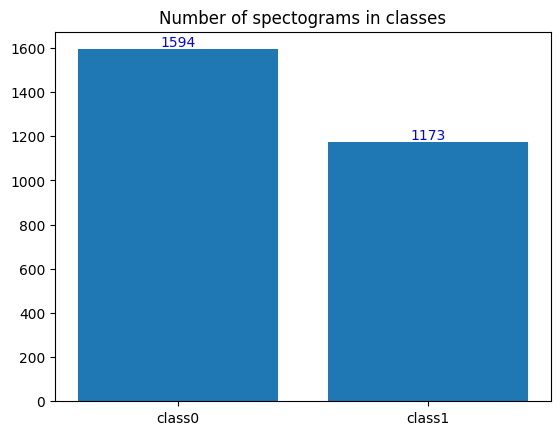

In [6]:
class0_count = len(class0_specs)
class1_count = len(class1_specs)

fig, ax = plt.subplots()
x_positions = [0, 1]
bars = ax.bar(['class0', 'class1'], [class0_count, class1_count])

ax.bar_label(bars, label_type='edge', color='blue')
ax.title.set_text('Number of spectograms in classes')
plt.show()



Pie chart for class distribution

In [ ]:
plt.figure(figsize=(6, 6))
class0_count = len(class0_specs)
class1_count = len(class1_specs)
plt.pie([class0_count, class1_count], labels=['class0', 'class1'], colors=['pink', 'violet'], autopct='%1.1f%%')

plt.title('Class Distribution spectrograms (%)')
plt.show()

Intensity distribution

C:\Users\piotrek\Desktop\PW\IML\voice_recognition\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


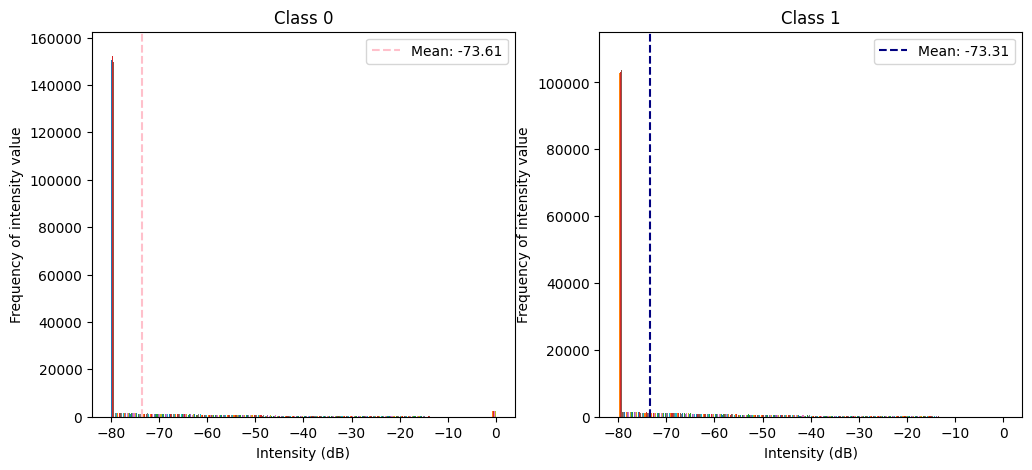

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#TODO explain
class0_values = np.concatenate(class0_specs)
class1_values = np.concatenate(class1_specs)

axes[0].hist(class0_values, bins=100)
axes[0].axvline(np.mean(class0_values), color='pink', linestyle='--', label=f'Mean: {np.mean(class0_values):.2f}')
axes[0].set_title('Class 0')
axes[0].set_xlabel('Intensity (dB)')
axes[0].set_ylabel('Frequency of intensity value')
axes[0].legend()

axes[1].hist(class1_values, bins=100)
axes[1].axvline(np.mean(class1_values), color='navy', linestyle='--', label=f'Mean: {np.mean(class1_values):.2f}')
axes[1].set_title('Class 1')
axes[1].set_xlabel('Intensity (dB)')
axes[1].set_ylabel('Frequency of intensity value')
axes[1].legend()
plt.show()

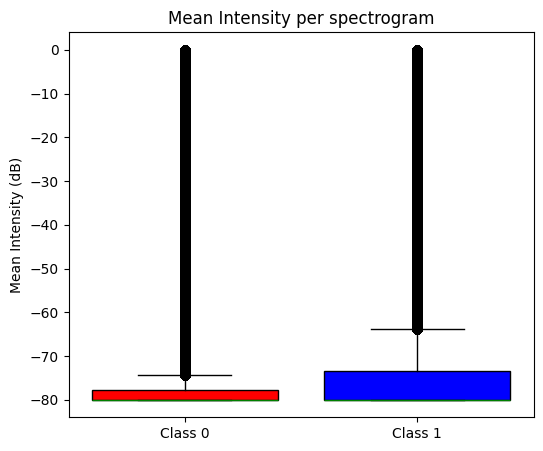

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot([class0_values.flatten(), class1_values.flatten()],
                tick_labels=['Class 0', 'Class 1'],
                 patch_artist=True,  # allows coloring
                 widths=0.8,
                medianprops=dict(color='green'))
#
bp['boxes'][0].set_facecolor('red')
bp['boxes'][1].set_facecolor('blue')

ax.set_title('Mean Intensity per spectrogram')
ax.set_ylabel('Mean Intensity (dB)')

plt.show()

Mean intensity distribution

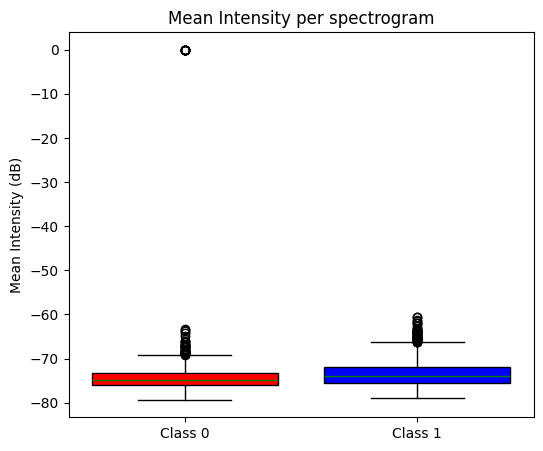

In [33]:
fig, ax = plt.subplots(figsize=(6, 5))

class0_means = [np.mean(s) for s in class0_specs]
class1_means = [np.mean(s) for s in class1_specs]
bp = ax.boxplot([class0_means, class1_means],
                tick_labels=['Class 0', 'Class 1'],
                 patch_artist=True,  # allows coloring
                 widths=0.8,
                medianprops=dict(color='green'))
#
bp['boxes'][0].set_facecolor('red')
bp['boxes'][1].set_facecolor('blue')

ax.set_title('Mean Intensity per spectrogram')
ax.set_ylabel('Mean Intensity (dB)')

plt.show()


TODO without 0??

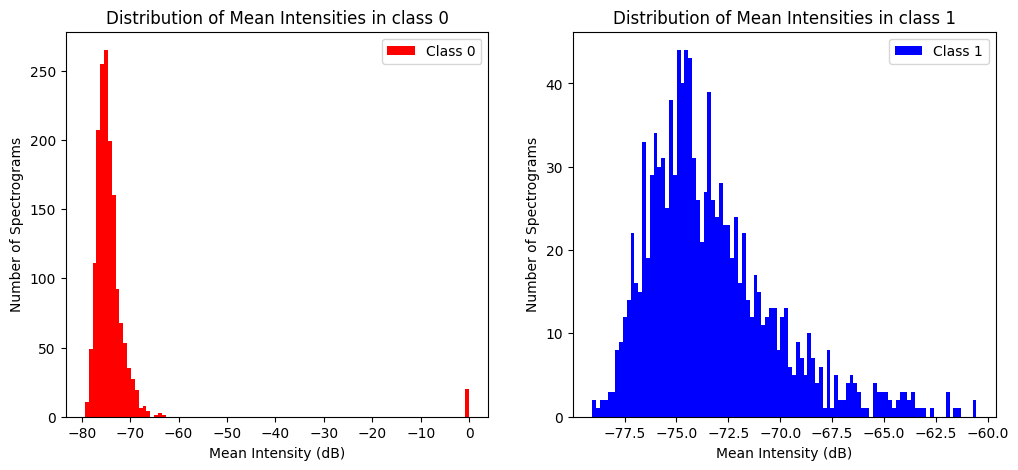

In [60]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
class0_means = [np.mean(s) for s in class0_specs]
class1_means = [np.mean(s) for s in class1_specs]
ax[0].hist(class0_means, bins=100, color='red', label='Class 0')
ax[1].hist(class1_means, bins=100, color='blue', label='Class 1')

ax[0].set_title('Distribution of Mean Intensities in class 0')
ax[0].set_xlabel('Mean Intensity (dB)')
ax[0].set_ylabel('Number of Spectrograms')
ax[0].legend()

ax[1].set_title('Distribution of Mean Intensities in class 1')
ax[1].set_xlabel('Mean Intensity (dB)')
ax[1].set_ylabel('Number of Spectrograms')
ax[1].legend()

plt.show()

Standard deviation of intensity

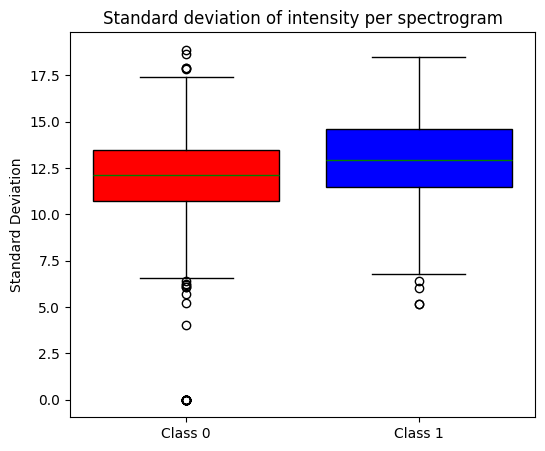

In [32]:
fig, ax = plt.subplots(figsize=(6, 5))

class0_means = [np.std(s) for s in class0_specs]
class1_means = [np.std(s) for s in class1_specs]
bp = ax.boxplot([class0_means, class1_means],
                tick_labels=['Class 0', 'Class 1'],
                 patch_artist=True,  # allows coloring
                 widths=0.8,
                 medianprops=dict(color='green'))
#
bp['boxes'][0].set_facecolor('red')
bp['boxes'][1].set_facecolor('blue')

ax.set_title('Standard deviation of intensity per spectrogram')
ax.set_ylabel('Standard Deviation')

plt.show()

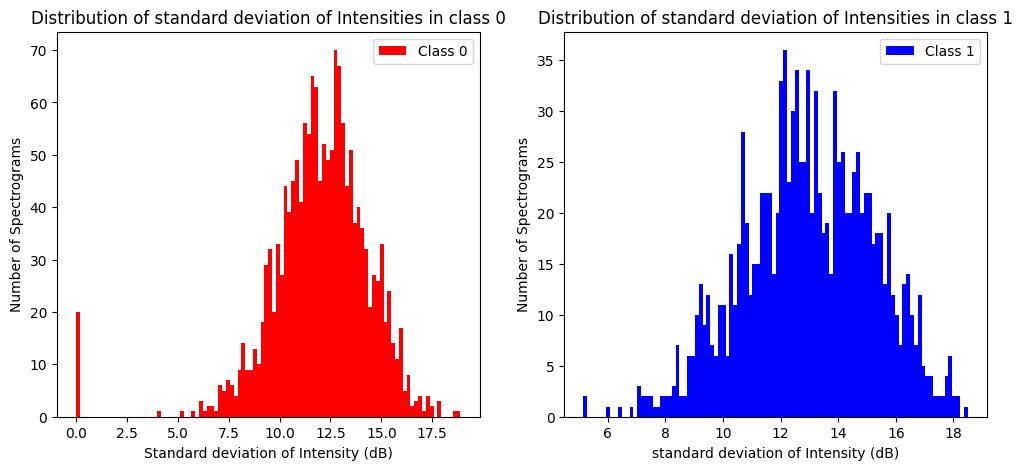

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
class0_means = [np.std(s) for s in class0_specs]
class1_means = [np.std(s) for s in class1_specs]
ax[0].hist(class0_means, bins=100, color='red', label='Class 0')
ax[1].hist(class1_means, bins=100, color='blue', label='Class 1')

ax[0].set_title('Distribution of standard deviation of Intensities in class 0')
ax[0].set_xlabel('Standard deviation of Intensity (dB)')
ax[0].set_ylabel('Number of Spectrograms')
ax[0].legend()

ax[1].set_title('Distribution of standard deviation of Intensities in class 1')
ax[1].set_xlabel('standard deviation of Intensity (dB)')
ax[1].set_ylabel('Number of Spectrograms')
ax[1].legend()

plt.show()

Max value of intensity per spectrogram

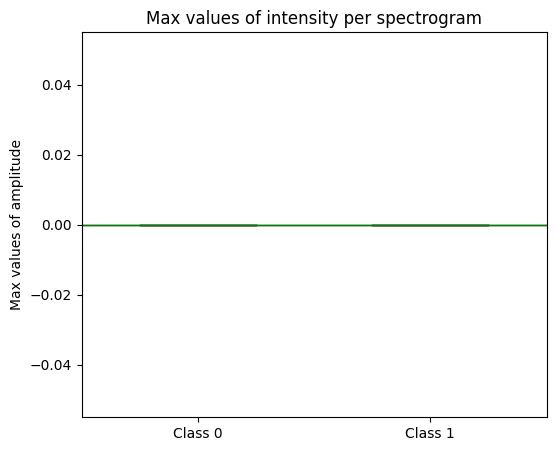

In [34]:
fig, ax = plt.subplots(figsize=(6, 5))

class0_means = [np.max(s) for s in class0_specs]
class1_means = [np.max(s) for s in class1_specs]
bp = ax.boxplot([class0_means, class1_means],
                tick_labels=['Class 0', 'Class 1'],
                 patch_artist=True,  # allows coloring
                 widths=1,
                 medianprops=dict(color='green'))
#
bp['boxes'][0].set_facecolor('red')
bp['boxes'][1].set_facecolor('blue')

ax.set_title('Max values of intensity per spectrogram')
ax.set_ylabel('Max values of amplitude')

plt.show()

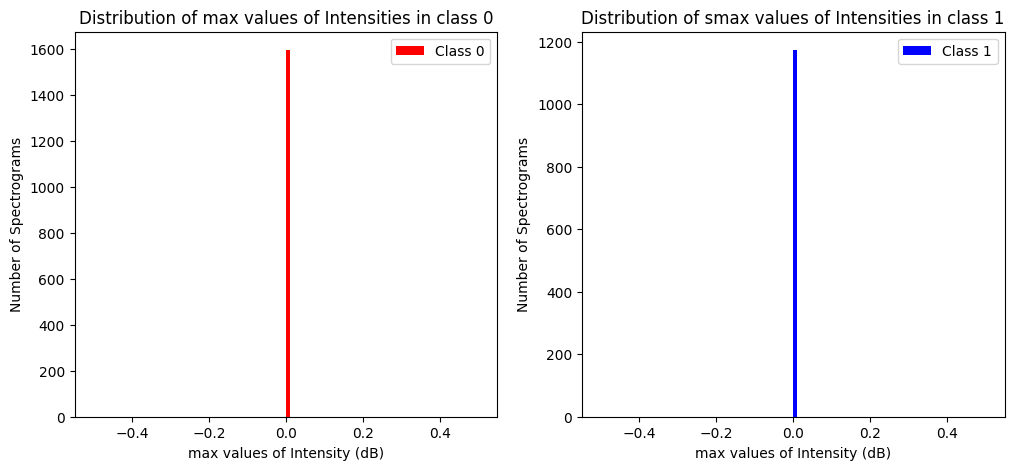

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
class0_means = [np.max(s) for s in class0_specs]
class1_means = [np.max(s) for s in class1_specs]
ax[0].hist(class0_means, bins=100, color='red', label='Class 0')
ax[1].hist(class1_means, bins=100, color='blue', label='Class 1')

ax[0].set_title('Distribution of max values of Intensities in class 0')
ax[0].set_xlabel('max values of Intensity (dB)')
ax[0].set_ylabel('Number of Spectrograms')
ax[0].legend()

ax[1].set_title('Distribution of max values of Intensities in class 1')
ax[1].set_xlabel('max values of Intensity (dB)')
ax[1].set_ylabel('Number of Spectrograms')
ax[1].legend()

plt.show()

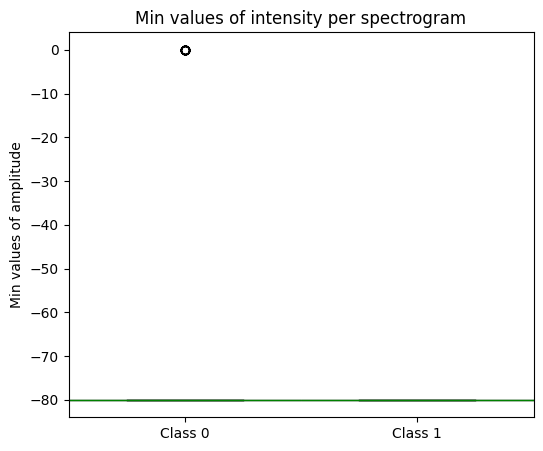

In [35]:
fig, ax = plt.subplots(figsize=(6, 5))

class0_means = [np.min(s) for s in class0_specs]
class1_means = [np.min(s) for s in class1_specs]
bp = ax.boxplot([class0_means, class1_means],
                tick_labels=['Class 0', 'Class 1'],
                 patch_artist=True,  # allows coloring
                 widths=1,
                 medianprops=dict(color='green'))
#
bp['boxes'][0].set_facecolor('red')
bp['boxes'][1].set_facecolor('blue')

ax.set_title('Min values of intensity per spectrogram')
ax.set_ylabel('Min values of amplitude')

plt.show()

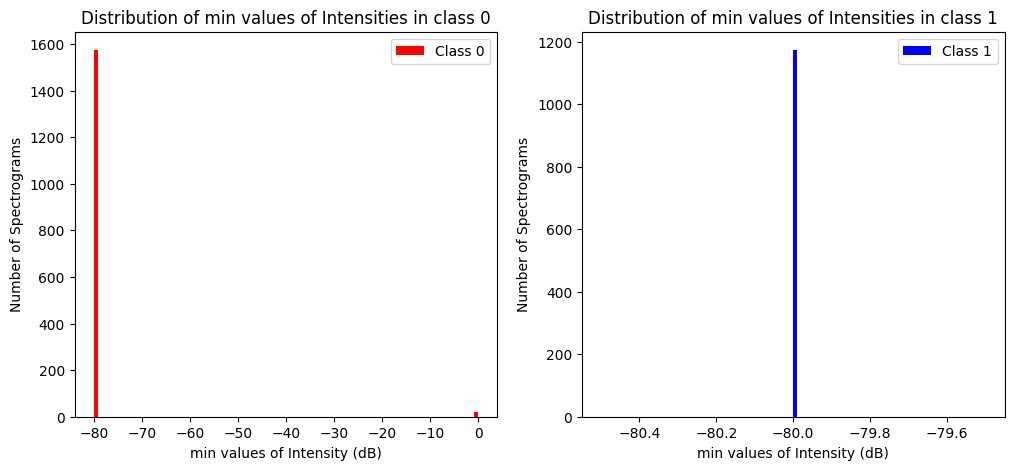

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
class0_means = [np.min(s) for s in class0_specs]
class1_means = [np.min(s) for s in class1_specs]
ax[0].hist(class0_means, bins=100, color='red', label='Class 0')
ax[1].hist(class1_means, bins=100, color='blue', label='Class 1')

ax[0].set_title('Distribution of min values of Intensities in class 0')
ax[0].set_xlabel('min values of Intensity (dB)')
ax[0].set_ylabel('Number of Spectrograms')
ax[0].legend()

ax[1].set_title('Distribution of min values of Intensities in class 1')
ax[1].set_xlabel('min values of Intensity (dB)')
ax[1].set_ylabel('Number of Spectrograms')
ax[1].legend()

plt.show()